# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

x0 = 24.60903 +/- 0.25928


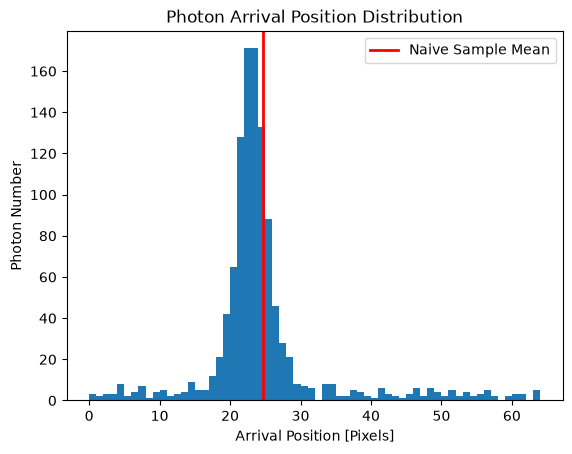

In [2]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt("../../labs/02/data/ratchev2.csv", delimiter = ",", skiprows = 1)
mean_naive = np.mean(x)
std_naive = np.std(x, ddof = 1)
x_sigma = std_naive / np.sqrt(len(x))

print("x0 =", round(mean_naive,5), "+/-", round(x_sigma, 5))

# the problem says the detections are in units of pixels with a window spanning [0, 64] pixels. Thus, I will choose my bins to be one bin per pixel
# in order to best represent the detector

hist_bins = np.arange(0, 65, 1)
plt.hist(x, bins = hist_bins)
plt.axvline(mean_naive, color = 'red', lw = '2', label = "Naive Sample Mean")
plt.legend()
plt.ylabel("Photon Number")
plt.xlabel("Arrival Position [Pixels]")
plt.title("Photon Arrival Position Distribution")
plt.show()

**ANSWER (a few sentences):**

*The sample mean as an estimator is biased for my dataset. This is because of the fact that the photon distribution is a mix of both the detected photons from the star and uniform background photons. Because the photons from the star are clearly on the smaller side of the 0 to 64 pixel interval, while the background photons are distributed uniformly, there are more total background photons at a higher pixel count (than the star photons, not the midpoint since the distribution is uniform) than there are at a lower pixel count. This can be seen simply in the histogram where there is much more "space" to the right of the histogram peak than to the left, meaning more total counts in that region. Since the mean treats all of these photons equally, the background pulls this estimator towards the midpoint position (32 pixels) and as a result pulls the estimator away from the true star position. Therefore, the bias is towards a larger x, and the magnitude of this bias is controlled by the background fraction f_bg. If there are more background photons compared to signal photons, then this pull will be stronger and the mean will move even closer towards the 32 pixel position. The magnitude of the bias also clearly depends on the difference between the detector midpoint at 32 pixels and the true star position. If the star position was exactly at 32 pixels, then we would expect no observable bias. If the star's position was at above 32 pixels, we would expect a bias toward a lower arrival position. However, with the current dataset, this bias is clearly toward a higher arrival position.*

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

Median: x0 =  23.28586 +/- 0.08374


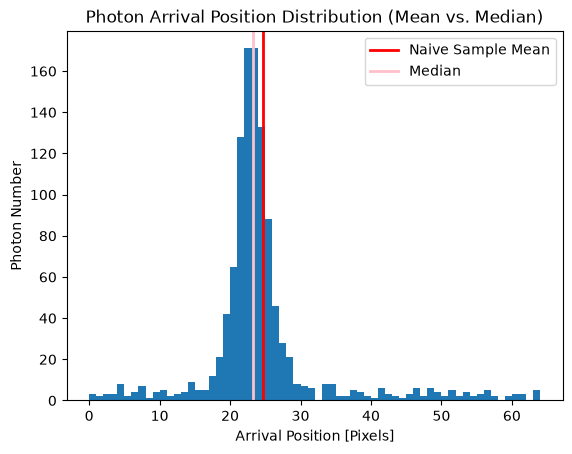

Sigma clipping: x0 = 23.177 +/- 0.10261
Sigma clipping: points clipped: 154


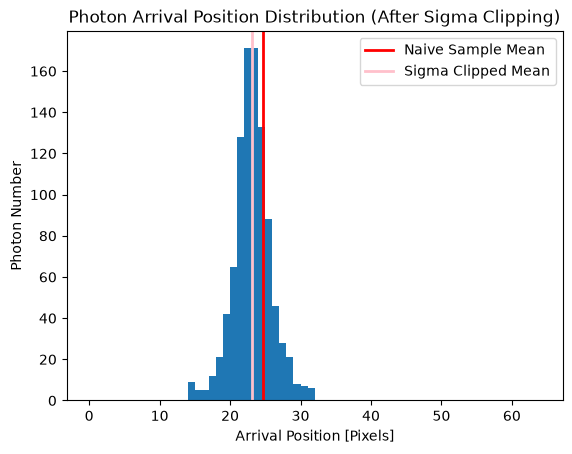

Mixture model: x0 = 23.16776 +/- 0.0829
Mixture model: f_bg = 0.17778 +/- 0.0835


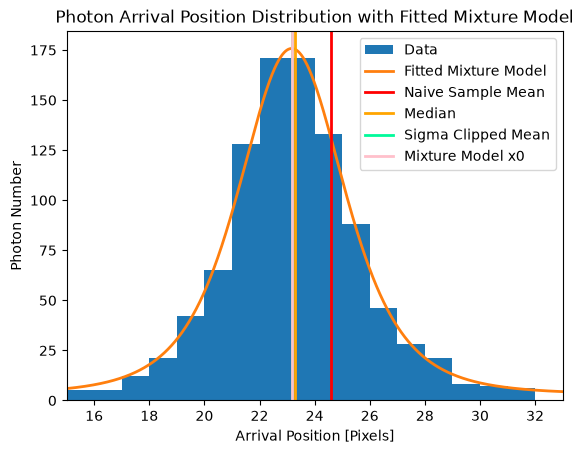

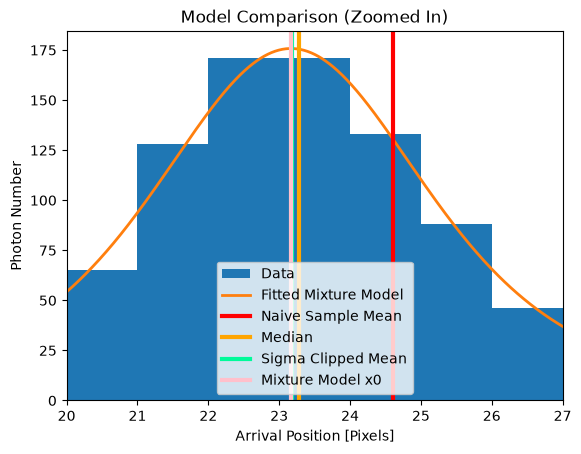

Final Results

Naive Sample Mean: x0 = 24.60903 +/- 0.25928
Median: x0 =  23.28586 +/- 0.08374
Sigma clipping: x0 = 23.177 +/- 0.10261
Mixture model: x0 = 23.16776 +/- 0.0829
Mixture model: f_bg = 0.17778 +/- 0.0835
Cramer Rao Bound for x0 = 0.08131


In [87]:
# Part 2: your work here

# median (I use bootstrapping to get the variance)

median = np.median(x)

r_num = np.random.default_rng(100000)
boot_num = 2000

m_boot_arr = np.empty(boot_num)

for i in range(boot_num):
    random_idxs = r_num.integers(0, len(x), size = len(x))
    m_boot_arr[i] = np.median(x[random_idxs])
median_sigma = np.std(m_boot_arr, ddof = 1)


print("Median: x0 = ", round(median, 5), "+/-", round(median_sigma, 5))
hist_bins = np.arange(0, 65, 1)
plt.hist(x, bins = hist_bins)
plt.axvline(mean_naive, color = 'red', lw = '2', label = "Naive Sample Mean")
plt.axvline(median, color = 'pink', lw = '2', label = "Median")
plt.legend()
plt.ylabel("Photon Number")
plt.xlabel("Arrival Position [Pixels]")
plt.title("Photon Arrival Position Distribution (Mean vs. Median)")
plt.show()

# sigma_clipping mean, I chose a sigma-clipping value of k = 3.5 because taking a lower value like k = 3 removes points that seem to be part of the main signal distribution (the distribution starts to look chopped
# off on both sides, while going with a value
# such as 4 results in tails on both sides of the star peak that clearly do not follow the same curve shape as the rest of the distribution, which implies that a good chunk of the background is still being
# considered. Thus, after confirming with the plots below, I went with k = 3.5 as this seems the most reasonable by eye.

def sigma_clipping(x, k, iteration_lim):
    clip_mask = np.full(len(x), True)
    for i in range(iteration_lim):
        curr_mean = np.mean(x[clip_mask])
        curr_std = np.std(x[clip_mask], ddof = 1)
        
        new_mask = np.abs(x - curr_mean) < k * curr_std
        
        break_out = True
        for j in range(len(clip_mask)):
            if (clip_mask[j] != new_mask[j]):
                break_out = False
                break
        if (break_out):
            break
            
        clip_mask = new_mask
    return clip_mask

sigma_mask = sigma_clipping(x, 3.5, 100)
sigma_clip_mean = np.mean(x[sigma_mask])

# using bootstrapping here as well:
r_num = np.random.default_rng(100000)
boot_num = 1000

s_boot_arr = np.empty(boot_num)

for i in range(boot_num):
    random_idxs = r_num.integers(0, len(x), size = len(x))
    s_boot_mask = sigma_clipping(x[random_idxs], 3.5, 100)
    s_boot_arr[i] = np.mean(x[s_boot_mask])
sc_mean_sigma = np.std(s_boot_arr, ddof = 1)

print("Sigma clipping: x0 =", round(sigma_clip_mean, 5), "+/-", round(sc_mean_sigma, 5))
print("Sigma clipping: points clipped:", np.sum(~sigma_mask))

hist_bins = np.arange(0, 65, 1)
plt.hist(x[sigma_mask], bins = hist_bins)
plt.axvline(mean_naive, color = 'red', lw = '2', label = "Naive Sample Mean")
plt.axvline(sigma_clip_mean, color = 'pink', lw = '2', label = "Sigma Clipped Mean")
plt.legend()
plt.ylabel("Photon Number")
plt.xlabel("Arrival Position [Pixels]")
plt.title("Photon Arrival Position Distribution (After Sigma Clipping)")
plt.show()

# mixture model
from scipy.optimize import minimize
from scipy.special import gamma
beta = 2.5
r_0 = 4

def mix_likelihood(z0, x):
    x0, f_bg = z0
    f_bg = np.clip(f_bg, 1e-6, 1 - 1e-6)
    
    star_term = (1 - f_bg) * gamma(beta) / (r_0 * np.sqrt(np.pi) * gamma(beta - 1/2)) * (1 + ((x - x0) / r_0)**2)**(-beta)
    bg_term = f_bg / 64

    return -np.sum(np.log(star_term + bg_term + 1e-300))

# I decided to start with the k-clipped mean as a guess and a background fraction of 0.25 as a guess
z0 = [sigma_clip_mean, 0.25] 
result = minimize(mix_likelihood, z0, args=(x,))
x0_mix, f_bg_mix = result.x
hess_inv = result.hess_inv # getting uncertainty from hess_inv estimate
x0_mix_sigma = np.sqrt(hess_inv[0,0])
f_bg_mix_sigma = np.sqrt(hess_inv[1, 1])

print("Mixture model: x0 =", round(x0_mix, 5), "+/-", round(x0_mix_sigma, 5))
print("Mixture model: f_bg =", round(f_bg_mix, 5), "+/-", round(f_bg_mix_sigma, 5))

xs = np.linspace(0, 64, 5000)
star_term = (1 - f_bg_mix) * gamma(beta) / (r_0 * np.sqrt(np.pi) * gamma(beta - 1/2)) * (1 + ((xs - x0_mix) / r_0)**2)**(-beta)
bg_term = f_bg_mix / 64

plt.hist(x, bins = hist_bins, label = "Data")
plt.plot(xs, len(x) * (star_term + bg_term), lw = '2', label = "Fitted Mixture Model")
plt.axvline(mean_naive, color = 'red', lw = '2', label = "Naive Sample Mean")
plt.axvline(median, color = 'orange', lw = '2', label = "Median")
plt.axvline(sigma_clip_mean, color = 'mediumspringgreen', lw = '2', label = "Sigma Clipped Mean")
plt.axvline(x0_mix, color = 'pink', lw = '2', label = "Mixture Model x0")
plt.xlim(15,33)
plt.legend()
plt.ylabel("Photon Number")
plt.xlabel("Arrival Position [Pixels]")
plt.title("Photon Arrival Position Distribution with Fitted Mixture Model")
plt.show()

plt.hist(x, bins = hist_bins, label = "Data")
plt.plot(xs, len(x) * (star_term + bg_term), lw = '2', label = "Fitted Mixture Model")
plt.axvline(mean_naive, color = 'red', lw = '3', label = "Naive Sample Mean")
plt.axvline(median, color = 'orange', lw = '3', label = "Median")
plt.axvline(sigma_clip_mean, color = 'mediumspringgreen', lw = '3', label = "Sigma Clipped Mean")
plt.axvline(x0_mix, color = 'pink', lw = '3', label = "Mixture Model x0")
plt.xlim(20, 27)
plt.legend()
plt.ylabel("Photon Number")
plt.xlabel("Arrival Position [Pixels]")
plt.title("Model Comparison (Zoomed In)")
plt.show()





def fisher_integral(x0, f_bg, x):
    xs = np.linspace(0, 64, 20000)
    
    star_term = (1 - f_bg) * gamma(beta) / (r_0 * np.sqrt(np.pi) * gamma(beta - 1/2)) * (1 + ((xs - x0) / r_0)**2)**(-beta)
    bg_term = f_bg / 64
    p = star_term + bg_term

    dp_dx0 = star_term * beta / (1 + ((xs - x0) / r_0)**2) * 2 * (xs - x0) / r_0**2
    dp_df_bg = 1 / 64 - star_term

    N = len(x)
    fisher_matrix = N * np.array([[np.trapezoid(dp_dx0**2 / p, xs), np.trapezoid(dp_dx0 * dp_df_bg / p, xs)], [np.trapezoid(dp_dx0 * dp_df_bg / p, xs), np.trapezoid(dp_df_bg**2 / p, xs)]])
    fisher_cov = np.linalg.inv(fisher_matrix)
    return fisher_cov
fisher_cov_m = fisher_integral(x0_mix, f_bg_mix, x)
x0_cr = np.sqrt(fisher_cov_m[0,0])

print("Final Results")
print("")
print("Naive Sample Mean: x0 =", round(mean_naive,5), "+/-", round(x_sigma, 5))
print("Median: x0 = ", round(median, 5), "+/-", round(median_sigma, 5))
print("Sigma clipping: x0 =", round(sigma_clip_mean, 5), "+/-", round(sc_mean_sigma, 5))
print("Mixture model: x0 =", round(x0_mix, 5), "+/-", round(x0_mix_sigma, 5))
print("Mixture model: f_bg =", round(f_bg_mix, 5), "+/-", round(f_bg_mix_sigma, 5))
print("Cramer Rao Bound for x0 =", round(x0_cr,5))

**FINAL ANSWER:** $x_0 = $ 23.16776 $\pm$ 0.0829 px , $f_{\rm bg} = $ 0.17778 $\pm$ 0.0835 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.08131 px

**Justification and uncertainty method (a short paragraph):**

When comparing our results with the Cramer Rao Bound, we can see immediately that the naive sample mean stands out the most as a biased estimator, as it has error bars over 3 times that of the Cramer Rao bound. This estimator clearly needs to be discarded as a result, especially since the uncertainty was calculated using a naive standard deviation method in which the background was included. The median is much more robust in that it does not get dragged as much by far points, however it is still biased towards the right due to the fact that there are more background counts on the right of the peak than to left due to the position of the peak. The uncertainty here was calculated with bootstrapping and is thus more trustworthy than the naive mean error, but we can do better. Sigma clipping is a better option than the median since it allows us to get rid of much of the background counts, however we cannot get rid of background counts in the same part of the detector as the star photons, and it is difficult to tell if I chose the correct sigma value that removed as much of the background as possible without touching the star distribution. The best option, and the one with the lowest uncertainty (closest to the Cramer Rao bound, while the median and sigma clipping errors are close as well but farther away) is the mixture model, in which we could separate the background data from the star data without removing any data points. Using the curvature allowed for an estimate of the uncertainty which was lower than the other estimators. I believe these uncertainties because they are obtained specifically from the curvature of the model. Thus, I will take this to be the best option.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. Closure: To check closure I will simulate a dataset with the same model as in this lab (star photons and background photons) using a Student-t distribution and known parameters (I will choose f_bg to be 0.25 and x_0 to be 35 pixels, with same photon number as I have for my personal data) and check to see if my estimator can recover these parameters to a reasonably close level. Failure would be indicated by a large difference between these stated parameter values and those my estimator returns (here I am defining large as being multiple times the estimated uncertainty)

2. Bias and efficiency: I will perform a Monte Carlo simulation using many simulated datasets with parameters near those from the real data. For each of these datasets I will calculate the bias and variance of all of my estimators and use a plot to compare these values to the Cramer-Rao bound I calculated in Part 2. I would expect the estimators (if unbiased and efficient) to have a bias and variance close to and above the Cramer-Rao bound. Failure would be if this is not the case and the variances are substantially larger than the Cramer-Rao bound or smaller than the Cramer-Rao bound
3. For the estimator, I will use the uncertainty estimate to obtain a 68% interval and then take the Monte Carlo simulations and count the fraction of the simulations for which the x0 value obtained is within this 68% interval. I will check to ensure that this is approximately 68% of the time. Failure would be clear by this percentage being much less or more than 68%.
4. I will change beta and r_0 to values above and below their true values and see how much the x0 estimate changes as a result. Failure here looks like the case of these changes resulting in x0 shifting by a sizable margin (larger than its reported uncertainty). I will also check what happens if the point source is close enough to a boundary that some photons do not get measured by the detectors and as such as the lost-photon fraction isnt negligible.

Closure:
True x0 = 35
True fbg = 0.25
Mean = 33.93163 +/- 0.28866
Median = 34.92902 +/- 0.10814
Sigma-clipped mean = 33.93163 +/- 0.52281
Mixture model x0 = 35.07634 +/- 0.08705
Mixture model f_bg = 0.25683 +/- 0.01585

Bias:
Mean: -0.75388
Median: -0.08221
Sigma-clipped Mean: -0.51564
Mixture Model: -0.00124

Variance:
Mean: 0.08059
Median: 0.01065
Sigma-clipped Mean: 0.20507
Mixture Model: 0.00766

CR bound:
x0: 0.08662
Variance: 0.0075


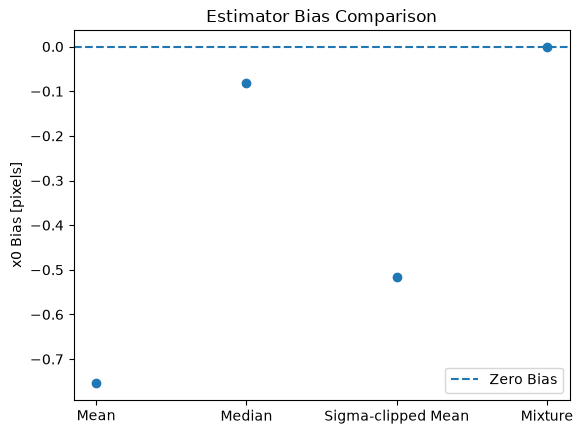

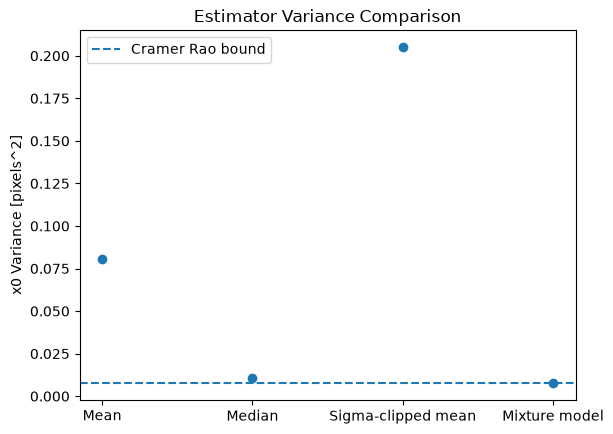


68% coverage:
Mean = 0.1
Median = 0.51
Sigma-clipped mean = 0.43
Mixture model = 0.59


In [112]:
# Part 3b: execute the plan here
from scipy.stats import t

real_x0 = 35
real_fbg = 0.25

beta = 2.5
r_0 = 4

r_num = np.random.default_rng(9999)
# 1 Closure
num_back = int(real_fbg * len(x))
num_star = len(x) - num_back

back_x = r_num.uniform(0, 64, num_back)
star_x = real_x0 + 2 * r_num.standard_t(2 * beta - 1, num_star)

full_x = np.concatenate([star_x, back_x])

mean_closure = np.mean(full_x)
mean_closure_sigma = np.std(full_x, ddof=1) / np.sqrt(len(full_x))

median_closure = np.median(full_x)
r_num = np.random.default_rng(9999)
boot_num = 1000
m_boot_arr = np.empty(boot_num)
for i in range(boot_num):
    random_idxs = r_num.integers(0, len(full_x), size=len(full_x))
    m_boot_arr[i] = np.median(full_x[random_idxs])
median_closure_sigma = np.std(m_boot_arr, ddof=1)
               
sigma_mask_closure = sigma_clipping(full_x, 3.5, 100)
sigma_clip_mean_closure = np.mean(full_x[sigma_mask_closure])
r_num = np.random.default_rng(9999)
boot_num = 1000
s_boot_arr = np.empty(boot_num)
for i in range(boot_num):
    random_idxs = r_num.integers(0, len(full_x), size=len(full_x))
    s_boot_mask = sigma_clipping(full_x[random_idxs], 3.5, 100)
    s_boot_arr[i] = np.mean(full_x[random_idxs][s_boot_mask])
sc_mean_closure_sigma = np.std(s_boot_arr, ddof=1)


z0 = [sigma_clip_mean_closure, 0.25]

result = minimize(mix_likelihood, z0, args=(full_x,))
x0_mix_closure, f_bg_mix_closure = result.x
x0_mix_closure_sigma = np.sqrt(result.hess_inv[0, 0])
f_bg_mix_closure_sigma = np.sqrt(result.hess_inv[1, 1])

print("Closure:")
print("True x0 =", round(real_x0, 5))
print("True fbg =", round(real_fbg, 5))
print("Mean =", round(mean_closure, 5), "+/-", round(mean_closure_sigma, 5))
print("Median =", round(median_closure, 5), "+/-", round(median_closure_sigma, 5))
print("Sigma-clipped mean =", round(sigma_clip_mean_closure, 5), "+/-", round(sc_mean_closure_sigma, 5))
print("Mixture model x0 =", round(x0_mix_closure, 5), "+/-", round(x0_mix_closure_sigma, 5))
print("Mixture model f_bg =", round(f_bg_mix_closure, 5), "+/-", round(f_bg_mix_closure_sigma, 5))




#2 Closure
num_sims = 1000
mean = np.empty(num_sims)
median = np.empty(num_sims)
sc_mean = np.empty(num_sims)
mixture = np.empty(num_sims)

for i in range(num_sims):
    num_back = int(real_fbg * len(x))
    num_star = len(x) - num_back
    back_x = r_num.uniform(0, 64, num_back)
    star_x = real_x0 + 2 * r_num.standard_t(2 * beta - 1, num_star)
    full_x = np.concatenate([star_x, back_x])

    mean[i] = np.mean(full_x)
    median[i] = np.median(full_x)
    sigma_mask_mc = sigma_clipping(full_x, 3.5, 100)
    sc_mean[i] = np.mean(full_x[sigma_mask_mc])

    z0 = [sc_mean[i], 0.25]
    result = minimize(mix_likelihood, z0, args=(full_x,))

    mixture[i] = result.x[0]

mean_bias = np.mean(mean) - real_x0
median_bias = np.mean(median) - real_x0
sc_mean_bias = np.mean(sc_mean) - real_x0
mix_bias = np.mean(mixture) - real_x0

mean_var = np.var(mean, ddof=1)
median_var = np.var(median, ddof=1)
sc_mean_var = np.var(sc_mean, ddof=1)
mix_var = np.var(mixture, ddof=1)

fisher_cov = fisher_integral(real_x0, real_fbg, x)
x0_cr = np.sqrt(fisher_cov[0, 0])
x0_cr_var = x0_cr**2

print("")
print("Bias:")
print("Mean:", round(mean_bias, 5))
print("Median:", round(median_bias, 5))
print("Sigma-clipped Mean:", round(sc_mean_bias, 5))
print("Mixture Model:", round(mix_bias, 5))

print("")
print("Variance:")
print("Mean:", round(mean_var, 5))
print("Median:", round(median_var, 5))
print("Sigma-clipped Mean:", round(sc_mean_var, 5))
print("Mixture Model:", round(mix_var, 5))

print("")
print("CR bound:")
print("x0:", round(x0_cr, 5))
print("Variance:", round(x0_cr_var, 5))


plt.scatter(["Mean", "Median", "Sigma-clipped Mean", "Mixture"],
            [mean_bias, median_bias, sc_mean_bias, mix_bias])
plt.axhline(0, linestyle="--", label="Zero Bias")
plt.ylabel("x0 Bias [pixels]")
plt.title("Estimator Bias Comparison")
plt.legend()
plt.show()



plt.scatter(["Mean", "Median", "Sigma-clipped mean", "Mixture model"],
            [mean_var, median_var, sc_mean_var, mix_var])
plt.axhline(x0_cr_var, linestyle="--", label="Cramer Rao bound")
plt.ylabel("x0 Variance [pixels^2]")
plt.title("Estimator Variance Comparison")
plt.legend()
plt.show()

#3 Coverage

# 3 Coverage
num_sims = 100
mean_count = 0
median_count = 0
sc_mean_count = 0
mix_count = 0

for i in range(num_sims):
    num_back = int(real_fbg * len(x))
    num_star = len(x) - num_back

    back_x = r_num.uniform(0, 64, num_back)
    star_x = real_x0 + 2 * r_num.standard_t(2 * beta - 1, num_star)

    full_x = np.concatenate([star_x, back_x])

    mean = np.mean(full_x)
    mean_sigma = np.std(full_x, ddof=1) / np.sqrt(len(full_x))
    if abs(mean - real_x0) <= mean_sigma:
        mean_count += 1

    median = np.median(full_x)
    m_boot_arr = np.empty(250)
    for j in range(250):
        random_idxs = r_num.integers(0, len(full_x), size=len(full_x))
        m_boot_arr[j] = np.median(full_x[random_idxs])

    median_sigma = np.std(m_boot_arr, ddof=1)
    if abs(median - real_x0) <= median_sigma:
        median_count += 1

    sigma_mask_mc = sigma_clipping(full_x, 3.5, 100)
    sc_mean = np.mean(full_x[sigma_mask_mc])
    s_boot_arr = np.empty(250)
    for j in range(250):
        random_idxs = r_num.integers(0, len(full_x), size=len(full_x))
        s_boot_mask = sigma_clipping(full_x[random_idxs], 3.5, 100)
        s_boot_arr[j] = np.mean(full_x[random_idxs][s_boot_mask])
    sc_mean_sigma = np.std(s_boot_arr, ddof=1)
    if abs(sc_mean - real_x0) <= sc_mean_sigma:
        sc_mean_count += 1

    z0 = [sc_mean, 0.25]
    result = minimize(mix_likelihood, z0, args=(full_x,))
    x0_mix = result.x[0]
    hess_inv = result.hess_inv
    x0_mix_sigma = np.sqrt(hess_inv[0, 0])
    if abs(x0_mix - real_x0) <= x0_mix_sigma:
        mix_count += 1

mean_coverage = mean_count / num_sims
median_coverage = median_count / num_sims
sc_mean_coverage = sc_mean_count / num_sims
mix_coverage = mix_count / num_sims

print("\n68% coverage:")
print("Mean =", round(mean_coverage, 5))
print("Median =", round(median_coverage, 5))
print("Sigma-clipped mean =", round(sc_mean_coverage, 5))
print("Mixture model =", round(mix_coverage, 5))

**WHAT THE CHECKS FOUND:**

1. Closure: All the estimators return x0 to a reasonable level with as shown in Part 2, the mixture model being clearly the best with the closest result to the true x0 with also a small uncertainty (along with that of the median). The same trend here between the estimators is seen as in Part 2 which is a good sign.
2. Bias and Efficiency: The Monte-Carlo simulations supported what I already suspected previously to a certain extent. As before, the naive sample mean was much farther away from the correct result than any of the other estimators, while the mixture model was the best choice overall by far in terms of bias. Interestingly, the sigma-clipped mean also performed much poorly than before, and I think this could be a result of the heavy tails of the Student-t distribution resulting in the throwing away of real stars. This means that the k value may have to be adjusted. When it comes to variance, everything is above the Cramer Rao bound, though the mixture model cuts it very close. The mixture model is the clear best result in terms of the variance here as well, with both the mean and sigma-clipped mean showing as biased estimators due to their variance values much greater than 3 times the Cramer-Rao bound. This part shows the success of the Mixture model and the basic median, while the failure of the other two estimators (though the sigma-clipping mean could potentially work if the k value is adjusted optimally, here however I stuck with what I used in Part 2).
3. Coverage: We can see that for the Mixture model the bounds are met the most percent of the time, with less for median, sigma-clipped, and mean. My computer was struggling to run too many runs which may have resulted in the mixture model being farther from 68% than anticipated, however it is clearly the best here. This does however mean that we should check the error method more carefully if it is the case that it does not converge to 68%. I suspect this may be due to the inverse Hessian approximation rather than getting an exact curvature.
4. I did not have time to complete this part

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*I didn't use any, I just refered to class materials and wrote/debugged code on my own.*